# PH04 — Huấn luyện ResNet18 trên HAM10000

Notebook này được chuyển từ `train_resnet.py` sang `.ipynb` để chạy local trên VS Code/Jupyter.

Mục tiêu:
- Dùng **ResNet18** để giảm nguy cơ overfitting khi source pretrain có khoảng 10k ảnh và fine-tune sau đó chỉ khoảng 1k ảnh.
- Lưu **best checkpoint** theo `val_acc`.
- Ghi **CSV log** gồm `epoch, train_loss, val_loss, val_acc, lr`.
- Vẽ biểu đồ bằng `matplotlib` để đưa vào báo cáo.

## 1. Import thư viện

In [1]:
import csv
import time
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models

import pandas as pd
import matplotlib.pyplot as plt


## 2. Thiết lập đường dẫn project

In [2]:
# Notebook dự kiến nằm trong thư mục notebooks/
PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / 'src'

import sys
sys.path.insert(0, str(SRC_DIR))

from dataset import SkinDataset, NUM_CLASSES
from transforms import get_resnet_transforms

SPLIT_DIR = PROJECT_ROOT / 'data' / 'splits'
CKPT_DIR  = PROJECT_ROOT / 'checkpoints'
LOG_DIR   = PROJECT_ROOT / 'logs'
RES_DIR   = PROJECT_ROOT / 'results'

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Project root : {PROJECT_ROOT}')
print(f'Device       : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')

Project root : c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT
Device       : cpu


## 3. Cấu hình train

In [ ]:
BATCH_SIZE   = 32
NUM_EPOCHS   = 10
LR           = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 0  # Windows an toàn hơn

print(f'BATCH_SIZE   = {BATCH_SIZE}')
print(f'NUM_EPOCHS   = {NUM_EPOCHS}')
print(f'LR           = {LR}')
print(f'WEIGHT_DECAY = {WEIGHT_DECAY}')
print(f'NUM_WORKERS  = {NUM_WORKERS}')

BATCH_SIZE   = 64
NUM_EPOCHS   = 10
LR           = 0.0001
WEIGHT_DECAY = 0.0001
NUM_WORKERS  = 0


## 4. Class weights cho dữ liệu mất cân bằng

In [4]:
def compute_class_weights(dataset):
    counts = dataset.df['label'].value_counts().sort_index()
    weights = 1.0 / counts.values.astype(float)
    weights = weights / weights.sum() * NUM_CLASSES
    return torch.tensor(weights, dtype=torch.float32)

## 5. Tạo dataset và dataloader

In [5]:
train_ds = SkinDataset(
    SPLIT_DIR / 'ham10000_train.csv',
    transform=get_resnet_transforms('train')
)

val_ds = SkinDataset(
    SPLIT_DIR / 'ham10000_val.csv',
    transform=get_resnet_transforms('val')
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f'Train : {len(train_ds):,}')
print(f'Val   : {len(val_ds):,}')

Train : 8,512
Val   : 1,503


## 6. Xây dựng ResNet18

In [6]:
def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, NUM_CLASSES),
    )
    return model


model = build_model().to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=compute_class_weights(train_ds).to(DEVICE))
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

print(model.fc)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=7, bias=True)
)


## 7. Hàm train và validate

In [7]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

## 8. Train ResNet18 và lưu best model

In [8]:
log_path = LOG_DIR / 'resnet18_log.csv'

with open(log_path, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss', 'val_acc', 'lr'])

best_val_acc = 0.0
unfreeze_done = False

for epoch in range(1, NUM_EPOCHS + 1):

    if epoch == 6 and not unfreeze_done:
        print('\n[Unfreeze] Mở backbone để fine-tune toàn bộ...')
        for p in model.parameters():
            p.requires_grad = True

        optimizer = torch.optim.Adam([
            {'params': model.fc.parameters(), 'lr': LR},
            {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': LR * 0.1},
        ], weight_decay=WEIGHT_DECAY)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
        unfreeze_done = True

    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    print(
        f'Epoch [{epoch:02d}/{NUM_EPOCHS}] ' +
        f'train_loss={train_loss:.4f} ' +
        f'val_loss={val_loss:.4f} ' +
        f'val_acc={val_acc:.4f} ' +
        f'({time.time() - t0:.1f}s)'
    )

    with open(log_path, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch,
            f'{train_loss:.6f}',
            f'{val_loss:.6f}',
            f'{val_acc:.6f}',
            f'{optimizer.param_groups[0]["lr"]:.2e}'
        ])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
            },
            CKPT_DIR / 'resnet18_best.pth'
        )
        print(f'✅ Saved best val_acc = {val_acc:.4f}')

print(f'\nDone. Best val_acc = {best_val_acc:.4f}')

Epoch [01/10] train_loss=2.0705 val_loss=1.9997 val_acc=0.1796 (228.6s)
✅ Saved best val_acc = 0.1796
Epoch [02/10] train_loss=1.9270 val_loss=1.8630 val_acc=0.3280 (226.2s)
✅ Saved best val_acc = 0.3280
Epoch [03/10] train_loss=1.8425 val_loss=1.7567 val_acc=0.3799 (224.5s)
✅ Saved best val_acc = 0.3799
Epoch [04/10] train_loss=1.7451 val_loss=1.6853 val_acc=0.4717 (223.5s)
✅ Saved best val_acc = 0.4717
Epoch [05/10] train_loss=1.6751 val_loss=1.6145 val_acc=0.4917 (223.2s)
✅ Saved best val_acc = 0.4917

[Unfreeze] Mở backbone để fine-tune toàn bộ...
Epoch [06/10] train_loss=1.4548 val_loss=1.2059 val_acc=0.5422 (467.9s)
✅ Saved best val_acc = 0.5422
Epoch [07/10] train_loss=1.1564 val_loss=1.0076 val_acc=0.5948 (444.4s)
✅ Saved best val_acc = 0.5948
Epoch [08/10] train_loss=0.9965 val_loss=0.8963 val_acc=0.6334 (445.0s)
✅ Saved best val_acc = 0.6334
Epoch [09/10] train_loss=0.8900 val_loss=0.8220 val_acc=0.6507 (448.3s)
✅ Saved best val_acc = 0.6507
Epoch [10/10] train_loss=0.8314 va

## 9. Đọc CSV log

In [9]:
df_log = pd.read_csv(log_path)
df_log

,epoch,train_loss,val_loss,val_acc,lr
0,1,2.070451,1.999739,0.179641,0.0001
1,2,1.927007,1.862970,0.328011,0.0001
2,3,1.842535,1.756739,0.379907,0.0001
3,4,1.745062,1.685274,0.471723,0.0001
4,5,1.675134,1.614455,0.491683,0.0001
5,6,1.454786,1.205908,0.542249,0.0001
6,7,1.156396,1.007576,0.594810,0.0001
7,8,0.996512,0.896308,0.633400,0.0001
8,9,0.890037,0.821980,0.650699,0.0001
9,10,0.831376,0.765539,0.697272,0.0001


## 10. Vẽ biểu đồ bằng matplotlib

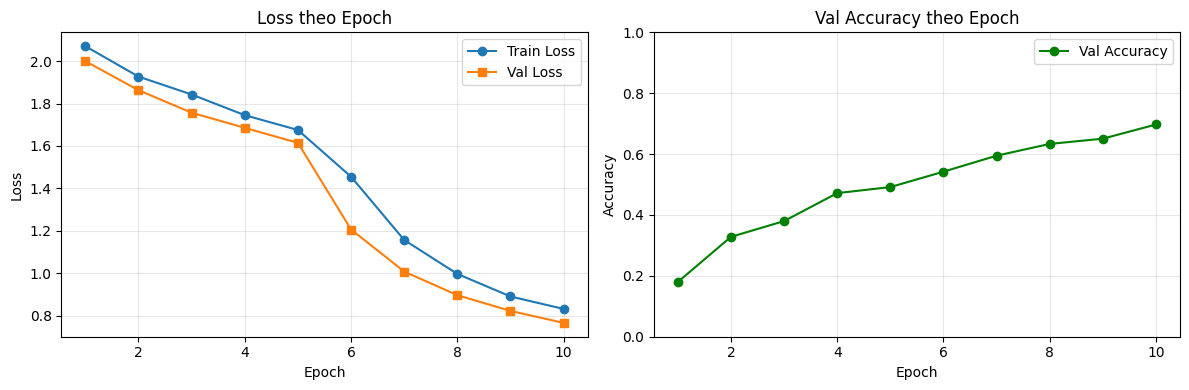

Đã lưu biểu đồ tại: c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\results\resnet18_training_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_log['epoch'], df_log['train_loss'], marker='o', label='Train Loss')
axes[0].plot(df_log['epoch'], df_log['val_loss'], marker='s', label='Val Loss')
axes[0].set_title('Loss theo Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_log['epoch'], df_log['val_acc'], marker='o', color='green', label='Val Accuracy')
axes[1].set_title('Val Accuracy theo Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR / 'resnet18_training_curves.png', dpi=150)
plt.show()

print(f'Đã lưu biểu đồ tại: {RES_DIR / "resnet18_training_curves.png"}')